<a href="https://colab.research.google.com/github/harshithachanta/logisticregression/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Logistic Regression**


Dataset link

https://drive.google.com/file/d/19O3hzFSf5Rr2QCO-Kn0lpUoZrDRnGbUD/view?usp=sharing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df=pd.read_csv("/content/bank-additional-full-1 (1) (1).csv",sep=";")

In [3]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Independent
-----------
housing-> has the housing loan or not

load-> has personal loan or not

month-> month of last ContextDecorator

day_of_week-> data of last contact

campaign -> how many times contacted.

pdays-> number of days since the client was last contacted

previous-> number of contacts before the current campaign

poutcome-> outcome of the previous campaign( success or not)


Dependent
----------
y-> Will take term deposit subscription or not

# Analysing the data

1) head, tail
2) info
3) shape
4) describe
5) columns
6) null values
7) duplicates
8) outliers


In [4]:
print(df.head())

    age        job  marital    education  default housing loan    contact  \
0  56.0  housemaid  married     basic.4y       no      no   no  telephone   
1  57.0   services  married  high.school  unknown      no   no  telephone   
2  37.0   services  married  high.school       no     yes   no  telephone   
3  40.0     admin.  married     basic.6y       no      no   no  telephone   
4  56.0   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
1   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
2   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
3   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   
4   may         mon  ...       1.0  999.0       0.0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.em

In [5]:
print(df.tail())

        age      job  marital            education default housing loan  \
41194  74.0  retired  married  professional.course      no     yes   no   
41195  74.0      NaN  married  professional.course      no     yes   no   
41196  74.0  retired  married                  NaN      no     yes   no   
41197   NaN      NaN      NaN                  NaN     NaN     NaN  NaN   
41198  74.0  retired  married  professional.course      no     yes  NaN   

        contact month day_of_week  ...  campaign  pdays  previous  poutcome  \
41194  cellular   nov         fri  ...       3.0  999.0       1.0   failure   
41195  cellular   nov         fri  ...       3.0  999.0       1.0   failure   
41196  cellular   nov         fri  ...       3.0  999.0       1.0   failure   
41197       NaN   NaN         NaN  ...       NaN    NaN       NaN       NaN   
41198  cellular   nov         fri  ...       3.0  999.0       1.0   failure   

      emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed 

In [6]:
print(df.shape)

(41199, 21)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [8]:
print(df.describe())

                age      duration      campaign         pdays      previous  \
count  41195.000000  41196.000000  41196.000000  41196.000000  41196.000000   
mean      40.030319    258.281265      2.567676    962.482547      0.173124   
std       10.431818    259.254211      2.769751    186.893451      0.494987   
min       17.000000      0.000000      1.000000      0.000000      0.000000   
25%       32.000000    102.000000      1.000000    999.000000      0.000000   
50%       38.000000    180.000000      2.000000    999.000000      0.000000   
75%       47.000000    319.000000      3.000000    999.000000      0.000000   
max       98.000000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41196.000000    41195.000000   41196.000000  41196.000000  41196.000000  
mean       0.081656       93.575867     -40.504600      3.620787   5166.996405  
std        1.570894        0.578999       4.6

Check null

In [9]:
print(df.isna().sum())

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64


In [10]:
#total number of rows with null values
n=df.isna().any(axis=1).sum()
print(n)

9


In [11]:
print(df.duplicated().sum())

15


In [12]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


Outliers

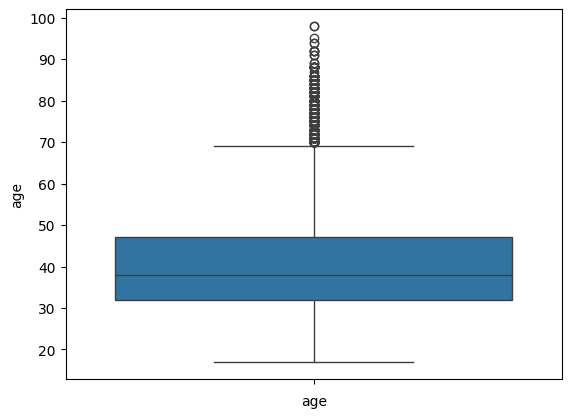

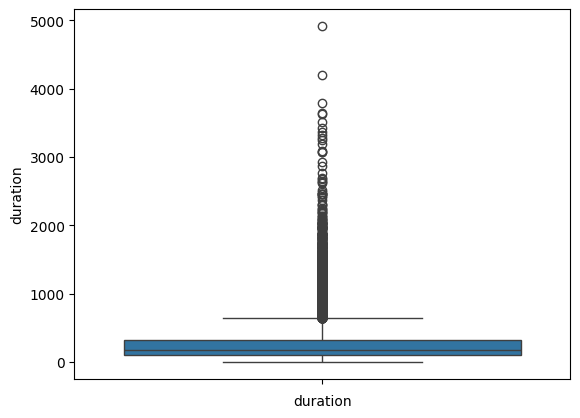

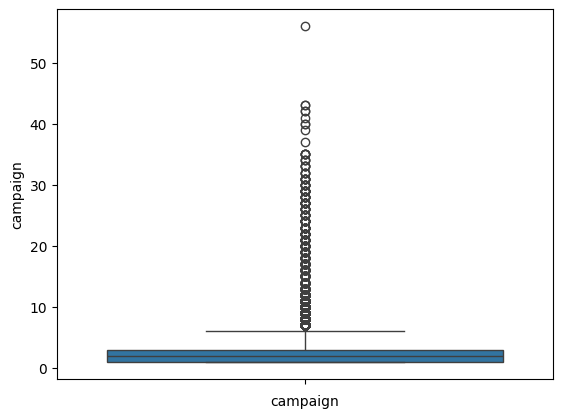

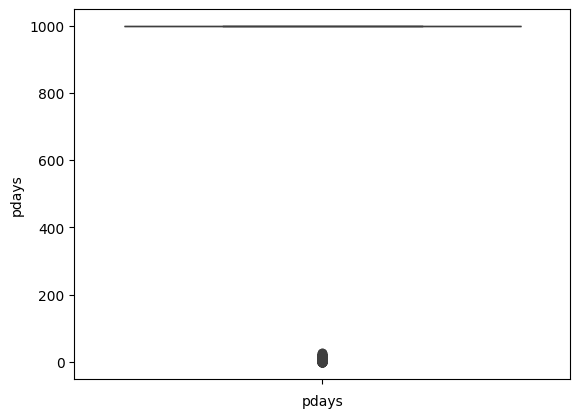

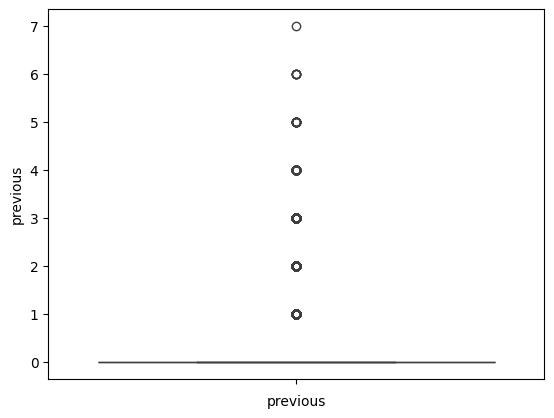

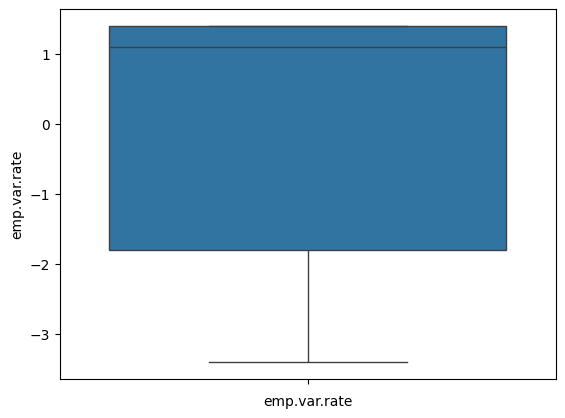

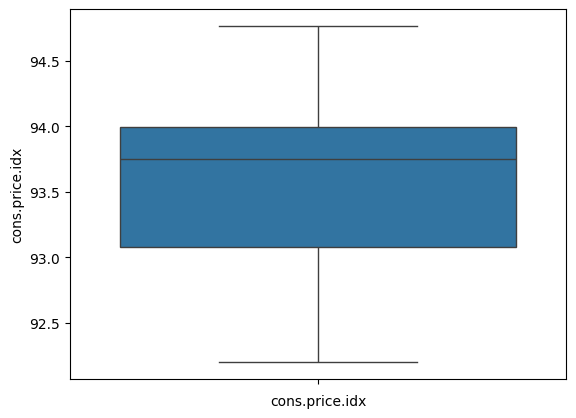

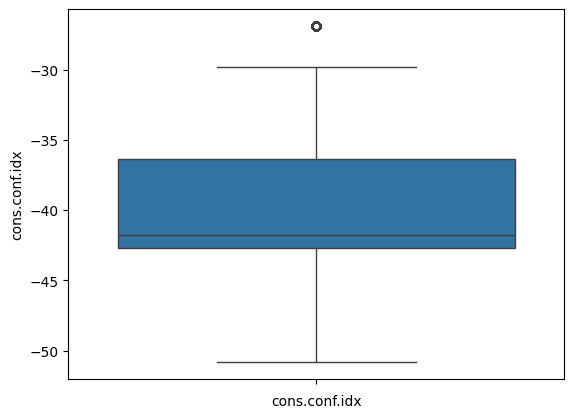

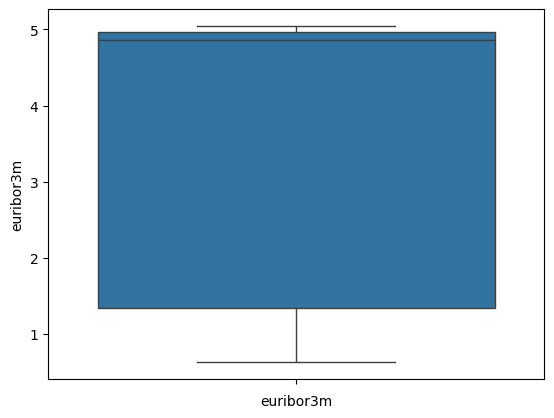

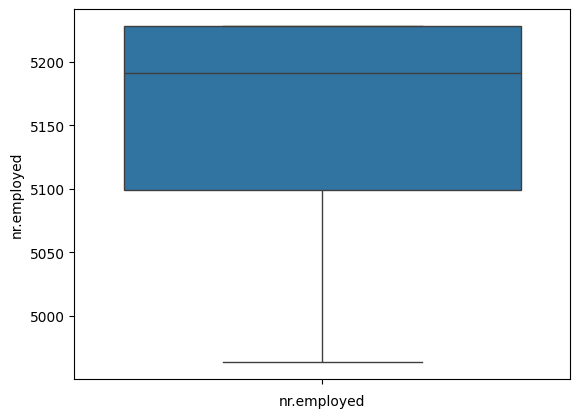

In [13]:
for i in df.columns:
  if(df[i].dtype=="int" or df[i].dtype=="float"):
    sb.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

#Cleaning The Data

na values

In [14]:
df.dropna(inplace=True)

drop duplicate

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
print(df.dtypes)

age               float64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration          float64
campaign          float64
pdays             float64
previous          float64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


**Label Encoding**

Converting categorical columns to numerical

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le=LabelEncoder()
for i in df.columns:
  if(df[i].dtype=="object"):
    df[i]=le.fit_transform(df[i])

In [19]:
df1=df.copy()
df2=df.copy()

In [20]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,...,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41184,46.0,1,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56.0,5,1,6,0,2,0,0,7,0,...,2.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44.0,9,1,5,0,0,0,0,7,0,...,1.0,999.0,0.0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41187,74.0,5,1,5,0,2,0,0,7,0,...,3.0,999.0,1.0,0,-1.1,94.767,-50.8,1.028,4963.6,0


**VIF**

Variance Inflation Factor, tells the the multicolliniarity level for columns( vif>5 -> high, vif>10 -> very high).

Columns which are corellates with each other, will have similar effect on the target column.

So the model gets confused on which to give more importance.



In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
def vif(df):
  #Independent colums
  cols=[]
  for i in df.columns:
    if i !="y":
      cols.append(i)
  data=df[cols]
  print()

  # dataframe which tells the vif of columns
  vif_scores=pd.DataFrame()
  vif_scores["Column"]=data.columns
  vif_scores["VIF"]=0

  v_values=[]
  # calculate the vif of each columns
  for i in range(len(cols)): # i-> 0,1,2,3,4
    v=variance_inflation_factor(data.values,i)
    v_values.append(v)

  vif_scores["VIF"]=v_values
  return vif_scores

In [23]:
vif(df)

,Column,VIF
0,age,19.731457
1,job,2.119972
2,marital,5.654315
3,education,4.462508
4,default,1.404238
5,housing,2.205822
6,loan,1.207857
7,contact,2.842605
8,month,6.777297
9,day_of_week,3.085104


In [24]:
def max_vif(df):
  col=df.loc[0]["Column"]
  v_max=df.loc[0]["VIF"]
  print(col)
  print(v_max)

  for i in range(len(df)):
    if (df.loc[i]["VIF"]>v_max):
      col=df.loc[i]["Column"]
      v_max=df.loc[i]["VIF"]

  # if vif >5 return the column
  if v_max>5:
    return col
  else:
    return ""

In [25]:
def remove_vif(df):
  vif_score= vif(df) #VIF table
  col= max_vif(vif_score) # col with max vif
  if col=="":
    print("No column with high VIF")
  else:
    print("Removed ",col)
    df.drop(col,axis=1,inplace=True) # remove the col
  print("New_VIF_Table")
  print(vif(df))


In [26]:
remove_vif(df)


age
19.73145654263685
Removed  nr.employed
New_VIF_Table

            Column         VIF
0              age   19.681090
1              job    2.119736
2          marital    5.653135
3        education    4.461946
4          default    1.401003
5          housing    2.205369
6             loan    1.207798
7          contact    2.394939
8            month    5.777664
9      day_of_week    3.084673
10        duration    2.011899
11        campaign    1.926484
12           pdays  165.456501
13        previous    5.878533
14        poutcome   33.894448
15    emp.var.rate   23.211602
16  cons.price.idx  703.151309
17   cons.conf.idx  110.381463
18       euribor3m  130.555155


In [27]:
remove_vif(df)


age
19.681090315505525
Removed  cons.price.idx
New_VIF_Table

           Column        VIF
0             age  18.513043
1             job   2.113730
2         marital   5.504581
3       education   4.412382
4         default   1.400977
5         housing   2.203837
6            loan   1.207421
7         contact   2.313469
8           month   5.741427
9     day_of_week   3.070689
10       duration   2.005797
11       campaign   1.924261
12          pdays  90.270681
13       previous   3.034860
14       poutcome  17.233539
15   emp.var.rate  16.756812
16  cons.conf.idx  71.619761
17      euribor3m  90.768190


In [28]:
remove_vif(df)


age
18.513042642528934
Removed  euribor3m
New_VIF_Table

           Column        VIF
0             age  17.913646
1             job   2.112616
2         marital   5.472544
3       education   4.369603
4         default   1.400846
5         housing   2.202038
6            loan   1.207310
7         contact   2.308489
8           month   5.275371
9     day_of_week   3.060463
10       duration   2.005589
11       campaign   1.924077
12          pdays  59.416154
13       previous   2.659418
14       poutcome  12.841182
15   emp.var.rate   1.623615
16  cons.conf.idx  70.553390


In [29]:
remove_vif(df)


age
17.91364588484178
Removed  cons.conf.idx
New_VIF_Table

          Column        VIF
0            age  17.912288
1            job   2.112007
2        marital   5.453106
3      education   4.359028
4        default   1.399665
5        housing   2.199567
6           loan   1.206772
7        contact   2.232469
8          month   5.248606
9    day_of_week   3.060456
10      duration   2.003035
11      campaign   1.914720
12         pdays  22.806159
13      previous   1.860685
14      poutcome   8.330671
15  emp.var.rate   1.582249


In [30]:
remove_vif(df)


age
17.912287549393458
Removed  pdays
New_VIF_Table

          Column       VIF
0            age  9.738658
1            job  2.096249
2        marital  4.261407
3      education  4.050511
4        default  1.398237
5        housing  2.152264
6           loan  1.203037
7        contact  2.230506
8          month  4.854342
9    day_of_week  2.952378
10      duration  1.974026
11      campaign  1.876540
12      previous  1.458600
13      poutcome  7.497222
14  emp.var.rate  1.562964


In [31]:
remove_vif(df)


age
9.738657826183944
Removed  age
New_VIF_Table

          Column       VIF
0            job  2.062373
1        marital  4.246947
2      education  3.894401
3        default  1.318533
4        housing  2.099373
5           loan  1.199446
6        contact  2.228936
7          month  4.566582
8    day_of_week  2.854055
9       duration  1.938419
10      campaign  1.828968
11      previous  1.415272
12      poutcome  6.128786
13  emp.var.rate  1.562478


In [32]:
remove_vif(df)


job
2.0623725812744
Removed  poutcome
New_VIF_Table

          Column       VIF
0            job  2.034715
1        marital  3.990531
2      education  3.639766
3        default  1.304721
4        housing  2.058117
5           loan  1.196540
6        contact  2.213453
7          month  4.382484
8    day_of_week  2.744288
9       duration  1.880818
10      campaign  1.793862
11      previous  1.366597
12  emp.var.rate  1.554971


In [33]:
remove_vif(df)


job
2.0347152987417325
No column with high VIF
New_VIF_Table

          Column       VIF
0            job  2.034715
1        marital  3.990531
2      education  3.639766
3        default  1.304721
4        housing  2.058117
5           loan  1.196540
6        contact  2.213453
7          month  4.382484
8    day_of_week  2.744288
9       duration  1.880818
10      campaign  1.793862
11      previous  1.366597
12  emp.var.rate  1.554971


In [34]:
print(df)

       job  marital  education  default  housing  loan  contact  month  \
0        3        1          0        0        0     0        1      6   
1        7        1          3        1        0     0        1      6   
2        7        1          3        0        2     0        1      6   
3        0        1          1        0        0     0        1      6   
4        7        1          3        0        0     2        1      6   
...    ...      ...        ...      ...      ...   ...      ...    ...   
41184    1        1          5        0        0     0        0      7   
41185    5        1          6        0        2     0        0      7   
41186    9        1          5        0        0     0        0      7   
41187    5        1          5        0        2     0        0      7   
41193    5        1          5        0        2     0        0      7   

       day_of_week  duration  campaign  previous  emp.var.rate  y  
0                1     261.0       1.0     

# RFE-> Recursive Feature Elimination

It's a feature selection method, used in Machine learning, used to choose the most important features for a model.

**Goal**-> Keep only the features that really helps the model predict the target, and remove the un-important features.


**How does it work?**

1) RFE internally trains and runs the model(Logistic regression) with all the features.

2) It checks and selects the least important feature and removes it.

3) Then it runs the model again ,after removing the least important feature and again finds the least imp feature.

4) Lastly, it gives us a list of all the features and tells us which are the features who are most important.

So we can find the best subset of the data to train our model.

**Why to remove the un-important?**

1) It shifts the focus from quantity to quality.

2) It becomes harder to find patterns when we have too many features.

3) Reduces computational cost, faster training, cheaper deployment.

4) Reduces the chance of **overfitting**


In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
model1=LogisticRegression(max_iter=1000)

In [37]:
from sklearn.feature_selection import RFE

In [38]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [39]:
rfe=RFE(model1)

In [43]:

rfe=RFE(model1,n_features_to_select=7)

In [44]:
rfe.fit(x,y) #By default it will stop removing when we have 50% of the features left
# rfe.fit(x,y,n_features_to_select=3)

RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=7)

In [46]:
print(list(rfe.support_))
print(list(df.columns))

[np.False_, np.True_, np.False_, np.True_, np.False_, np.False_, np.True_, np.True_, np.True_, np.False_, np.False_, np.True_, np.True_]
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'previous', 'emp.var.rate', 'y']


In [47]:
imp=[]
test=rfe.support_
for i in range(len(test)):
  if test[i]==True:
    imp.append(i)
print(imp)

[1, 3, 6, 7, 8, 11, 12]


In [48]:
df.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'emp.var.rate', 'y'],
      dtype='object')

In [49]:
imp_features=df.columns[imp]
print(imp_features)

Index(['marital', 'default', 'contact', 'month', 'day_of_week', 'previous',
       'emp.var.rate'],
      dtype='object')


In [51]:
data=df[imp_features]

In [52]:
print(data)

       marital  default  contact  month  day_of_week  previous  emp.var.rate
0            1        0        1      6            1       0.0           1.1
1            1        1        1      6            1       0.0           1.1
2            1        0        1      6            1       0.0           1.1
3            1        0        1      6            1       0.0           1.1
4            1        0        1      6            1       0.0           1.1
...        ...      ...      ...    ...          ...       ...           ...
41184        1        0        0      7            0       0.0          -1.1
41185        1        0        0      7            0       0.0          -1.1
41186        1        0        0      7            0       0.0          -1.1
41187        1        0        0      7            0       1.0          -1.1
41193        1        0        0      7            0       1.0          -1.1

[41177 rows x 7 columns]


In [54]:
data["y"]=df["y"]

/tmp/ipykernel_10518/1819414967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["y"]=df["y"]


In [55]:
print(data)

       marital  default  contact  month  day_of_week  previous  emp.var.rate  \
0            1        0        1      6            1       0.0           1.1   
1            1        1        1      6            1       0.0           1.1   
2            1        0        1      6            1       0.0           1.1   
3            1        0        1      6            1       0.0           1.1   
4            1        0        1      6            1       0.0           1.1   
...        ...      ...      ...    ...          ...       ...           ...   
41184        1        0        0      7            0       0.0          -1.1   
41185        1        0        0      7            0       0.0          -1.1   
41186        1        0        0      7            0       0.0          -1.1   
41187        1        0        0      7            0       1.0          -1.1   
41193        1        0        0      7            0       1.0          -1.1   

       y  
0      0  
1      0  
2     

# Creating the model

1) Split the data into indepented and dependent

In [56]:
x=data.iloc[:,:-1]
y=data.iloc[:,-1]

In [57]:
print(x)

       marital  default  contact  month  day_of_week  previous  emp.var.rate
0            1        0        1      6            1       0.0           1.1
1            1        1        1      6            1       0.0           1.1
2            1        0        1      6            1       0.0           1.1
3            1        0        1      6            1       0.0           1.1
4            1        0        1      6            1       0.0           1.1
...        ...      ...      ...    ...          ...       ...           ...
41184        1        0        0      7            0       0.0          -1.1
41185        1        0        0      7            0       0.0          -1.1
41186        1        0        0      7            0       0.0          -1.1
41187        1        0        0      7            0       1.0          -1.1
41193        1        0        0      7            0       1.0          -1.1

[41177 rows x 7 columns]


In [58]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41184,0
41185,0
41186,1
41187,0


2) Split data into train/test

In [59]:
from sklearn.model_selection import train_test_split

x -> input   y-> output

x_train      y_train
x_test
model gives -> y_pred


compare y_pred, y_test

In [60]:
x_train,x_test,y_train,y_test= train_test_split(x,y)

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
model=LogisticRegression()

Train model

In [63]:
model.fit(x_train,y_train)

LogisticRegression()

Predict output

In [64]:
y_pred=model.predict(x_test)

In [65]:
print(y_pred)

[0 0 0 ... 0 0 0]


# Checking the accuracy of model prediction

**Confusion Matrix**

Tells us how many predictions our model got right and wrong.

**Tn- True negative**

How are actually 0 and your model also said 0

**Fp- False Positive**

How many, did model said 1, but actually they were 0

**FN- False Negative**

How many positive values, did you say were negative.

Values were actually 1 , but you said 0

**TP-> True Positive**

How many were 1, you also said 1

In [ ]:
             Predicted
            0       1
        0  TN      FP
Actual
        1  FN      TP

              Pred
            0      1
        0  9095,   38 -> total 0= 9133
 Actual
        1  1120,   42 -> total 1= 1162

TN=9095
FP= 38
FN= 1120
TP= 42

Total output= Tn+fp+fn+tp

Correct= Tp+Tn

Incorrect= Fp+Fn

In [66]:
from sklearn.metrics import *

In [67]:
confusion_matrix(y_test,y_pred)

array([[9099,   36],
       [1115,   45]])

**1) Accuracy Score**

Out of all the predictions, how many were correct.

accuracy= correct / total

In [69]:
TN=9095
FP= 38
FN= 1120
TP= 42

Total= TN+FP+FN+TP

Correct= TP+TN

acc=Correct/Total
print("Accuracy=",acc*100,"%")

Accuracy= 88.75182127246237 %


In [70]:
print(data["y"].value_counts())

y
0    36538
1     4639
Name: count, dtype: int64


**Example:**
**Chekcing if people have covid or not**

1000 people

990 healthy ( no)

10 covid (yes)

Model-> 1000 are healthy

yes=0, no=1000

accuracy= 990/1000 -> 99%


**Accuracy is misleading**

- when data is un-balanced





It treats,

false positive and false negative as equally bad.

Accuracy -> how often am i right?

But real question is -> Am I wrong in dangerous ways?

**2) Precision Score**

Out of all the positive prediction(1) , how many are actually 1.

In [71]:
Total_pred_positve= FP+TP
Actually_pos= TP

precision = TP/Total_pred_positve

print("Precision=",precision*100,"%")


Precision= 52.5 %


100 people

10 covid

model said 1 is covid

positive = 1

And that is actually positive,

so precision = 100%


**3) Recall**

Out of all the actual positive , how many did you identify. '


10 covid-> 1 identified

recall= 1/10, 10%

Recall= TP / Total positive

In [72]:
recall=TP / (TP+ FN)
print("Recall for 1=",recall*100,"%")

Recall for 1= 3.614457831325301 %


In [73]:
accuracy_score(y_test,y_pred)

0.8881981544439048

In [74]:
precision_score(y_test,y_pred)

0.5555555555555556

In [77]:
recall_score(y_test,y_pred)

0.03879310344827586

In [78]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      9135
           1       0.56      0.04      0.07      1160

    accuracy                           0.89     10295
   macro avg       0.72      0.52      0.51     10295
weighted avg       0.85      0.89      0.84     10295



**4) F1 score**

Recall-> checks for amount of positive caught

Precison -> check if the caught ones are positive


F1 focuses of quality of positive ( precision) + coverage of positive(Recall)

F1= 2x(Precision x Recall) / (Presion+Recall)

In [79]:
print(f1_score(y_test,y_pred)*100,"%")

7.2522159548751 %
